In [3]:
#Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt


In [12]:
#Upload do arquivo
from google.colab import files
arq = files.upload()

Saving Sales.SalesOrderHeader.xlsx to Sales.SalesOrderHeader.xlsx


In [13]:
#Criando nosso dataframe
df = pd.read_excel('Sales.SalesOrderHeader.xlsx')

In [14]:
#Visualizando as 5 primeras linhas
df.head()

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,CreditCardID,CreditCardApprovalCode,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,Comment,rowguid,ModifiedDate
0,2019-07-13,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43659,PO522145787,10-4020-000676,...,16281.0,105041Vi84182,NaN,20565.6206,1971.5149,616.0984,23153.2339,NaN,79B65321-39CA-4115-9CBA-8FE0903E12E6,2011-06-07
1,2019-07-14,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43660,PO18850127500,10-4020-000117,...,5618.0,115213Vi29411,NaN,1294.2529,124.2483,38.8276,1457.3288,NaN,738DC42D-D03B-48A1-9822-F95A67EA7389,2011-06-07
2,2019-07-15,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43661,PO18473189620,10-4020-000442,...,1346.0,85274Vi6854,4.0,32726.4786,3153.7696,985.5530,36865.8012,NaN,D91B9131-18A4-4A11-BC3A-90B6F53E9D74,2011-06-07
3,2019-07-16,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43662,PO18444174044,10-4020-000227,...,10456.0,125295Vi53935,4.0,28832.5289,2775.1646,867.2389,32474.9324,NaN,4A1ECFC0-CC3A-4740-B028-1C50BB48711C,2011-06-07
4,2019-07-17,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43663,PO18009186470,10-4020-000510,...,4322.0,45303Vi22691,NaN,419.4589,40.2681,12.5838,472.3108,NaN,9B1E7A40-6AE0-4AD3-811C-A64951857C4B,2011-06-07


In [15]:
#Quantidade de linhas e colunas
df.shape

(31465, 26)

In [16]:
#Verificando tipos de dados
df.dtypes

,0
SalesOrderID,datetime64[ns]
RevisionNumber,int64
OrderDate,datetime64[ns]
DueDate,datetime64[ns]
ShipDate,datetime64[ns]
Status,int64
OnlineOrderFlag,int64
SalesOrderNumber,object
PurchaseOrderNumber,object
AccountNumber,object


In [17]:
#Qual a receita total?
df['SubTotal'].sum()

np.float64(109846381.4039)

In [ ]:
#Qual o custo total? (ex)
df['TotalDue'] = df['Custo Unitário'].mul(df['Quantidade'])#Criando a coluna de custo

In [19]:
df.head(1)

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,CreditCardID,CreditCardApprovalCode,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,Comment,rowguid,ModifiedDate
0,2019-07-13,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43659,PO522145787,10-4020-000676,...,16281.0,105041Vi84182,NaN,20565.6206,1971.5149,616.0984,23153.2339,NaN,79B65321-39CA-4115-9CBA-8FE0903E12E6,2011-06-07


In [20]:
#Qual o custo total?
round(df['TotalDue'].sum(), 2)

np.float64(123216786.12)

In [21]:
#Agora que temops a receita e o custo total, podemos achar o lucro total
#Vamos criar uma coluna de lucro que será Receita - Custo
df['Lucro'] = df['SubTotal'] - df['TotalDue']

In [22]:
df.head(1)

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,CreditCardApprovalCode,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,Comment,rowguid,ModifiedDate,Lucro
0,2019-07-13,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43659,PO522145787,10-4020-000676,...,105041Vi84182,NaN,20565.6206,1971.5149,616.0984,23153.2339,NaN,79B65321-39CA-4115-9CBA-8FE0903E12E6,2011-06-07,-2587.6133


In [23]:
#Total lucro
round(df['Lucro'].sum(),2)

np.float64(-13370404.71)

In [24]:
#Criando uma coluna com total de dias para enviar o produto
df['Tempo_envio'] = df['ShipDate'] - df['OrderDate']

In [25]:
df.head(1)

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,Comment,rowguid,ModifiedDate,Lucro,Tempo_envio
0,2019-07-13,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43659,PO522145787,10-4020-000676,...,NaN,20565.6206,1971.5149,616.0984,23153.2339,NaN,79B65321-39CA-4115-9CBA-8FE0903E12E6,2011-06-07,-2587.6133,7 days


Agora queremmos saber a média do tempo de envio para cada Marca, e para isso precisamos transformar a coluna Tempo_envio em númerica

In [26]:
#Extraindo apenas os dias
df['Tempo_envio'] = (df['ShipDate'] - df['OrderDate']).dt.days

In [27]:
df.head(1)

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,Comment,rowguid,ModifiedDate,Lucro,Tempo_envio
0,2019-07-13,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43659,PO522145787,10-4020-000676,...,NaN,20565.6206,1971.5149,616.0984,23153.2339,NaN,79B65321-39CA-4115-9CBA-8FE0903E12E6,2011-06-07,-2587.6133,7


In [28]:
#Verificando o tipo da coluna Tempo_envio
df['Tempo_envio'].dtype

dtype('int64')

In [29]:
#Média do tempo de envio por Marca
df.groupby('SalesOrderID') ['Tempo_envio'].mean()

,Tempo_envio
SalesOrderID,
2019-07-13,7.0
2019-07-14,7.0
2019-07-15,7.0
2019-07-16,7.0
2019-07-17,7.0
...,...
2105-08-31,7.0
2105-09-01,7.0
2105-09-02,7.0


Missing Values

In [31]:
#Verificando se temos dados faltantes
df.isnull().sum()

,0
SalesOrderID,0
RevisionNumber,0
OrderDate,0
DueDate,0
ShipDate,0
Status,0
OnlineOrderFlag,0
SalesOrderNumber,0
PurchaseOrderNumber,27659
AccountNumber,0


E se a gente quiser saber o Lucro por Ano e por Marca?

In [35]:
#Vamos agrupar por ano e marca
df.groupby([df['OrderDate'].dt.year, 'SalesOrderID'])['Lucro'].sum()

OrderDate  SalesOrderID
2011       2019-07-13                -2,587.61
           2019-07-14                  -163.08
           2019-07-15                -4,139.32
           2019-07-16                -3,642.40
           2019-07-17                   -52.85
                                  ...         
2014       2105-08-31                    -4.44
           2105-09-01                    -8.92
           2105-09-02                    -7.87
           2105-09-03                    -3.25
           2105-09-04                   -19.95
Name: Lucro, Length: 31465, dtype: float64

In [34]:
pd.options.display.float_format = '{:20,.2f}'.format

In [36]:
#Resetando o index
lucro_ano = df.groupby([df['OrderDate'].dt.year, 'SalesOrderID'])['Lucro'].sum().reset_index()
lucro_ano

,OrderDate,SalesOrderID,Lucro
0,2011,2019-07-13,"-2,587.61"
1,2011,2019-07-14,-163.08
2,2011,2019-07-15,"-4,139.32"
3,2011,2019-07-16,"-3,642.40"
4,2011,2019-07-17,-52.85
...,...,...,...
31460,2014,2105-08-31,-4.44
31461,2014,2105-09-01,-8.92
31462,2014,2105-09-02,-7.87
31463,2014,2105-09-03,-3.25


In [ ]:
#Qual o total de produtos vendidos? (ex)
df.groupby('PurchaseOrderNumber')['Quantidade'].sum().sort_values(ascending=False)

In [ ]:
#Gráfico total de produtos vendidos
df.groupby('PurchaseOrderNumber')['Quantidade'].sum().sort_values(ascending=True).plot.barh(title='Total Produtos Vendidos')
plt.xlabel('Total')
plt.ylabel('Produto');

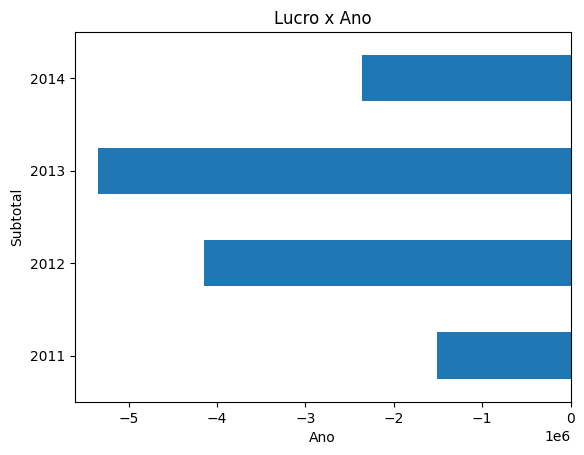

In [38]:
df.groupby(df['OrderDate'].dt.year)['Lucro'].sum().plot.barh(title='Lucro x Ano')
plt.xlabel('Ano')
plt.ylabel('Subtotal');

In [39]:
df.groupby(df['OrderDate'].dt.year)['Lucro'].sum()

,Lucro
OrderDate,
2011,"-1,514,027.31"
2012,"-4,151,398.99"
2013,"-5,343,408.91"
2014,"-2,361,569.50"


In [42]:
#Selecionando apenas as vendas de 2009
df_2011 = df[df['OrderDate'].dt.year == 2011]

In [43]:
df_2011.head()

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,Comment,rowguid,ModifiedDate,Lucro,Tempo_envio
0,2019-07-13,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43659,PO522145787,10-4020-000676,...,NaN,"20,565.62","1,971.51",616.10,"23,153.23",NaN,79B65321-39CA-4115-9CBA-8FE0903E12E6,2011-06-07,"-2,587.61",7
1,2019-07-14,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43660,PO18850127500,10-4020-000117,...,NaN,"1,294.25",124.25,38.83,"1,457.33",NaN,738DC42D-D03B-48A1-9822-F95A67EA7389,2011-06-07,-163.08,7
2,2019-07-15,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43661,PO18473189620,10-4020-000442,...,4.00,"32,726.48","3,153.77",985.55,"36,865.80",NaN,D91B9131-18A4-4A11-BC3A-90B6F53E9D74,2011-06-07,"-4,139.32",7
3,2019-07-16,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43662,PO18444174044,10-4020-000227,...,4.00,"28,832.53","2,775.16",867.24,"32,474.93",NaN,4A1ECFC0-CC3A-4740-B028-1C50BB48711C,2011-06-07,"-3,642.40",7
4,2019-07-17,8,2011-05-31,2011-06-12,2011-06-07,5,0,SO43663,PO18009186470,10-4020-000510,...,NaN,419.46,40.27,12.58,472.31,NaN,9B1E7A40-6AE0-4AD3-811C-A64951857C4B,2011-06-07,-52.85,7


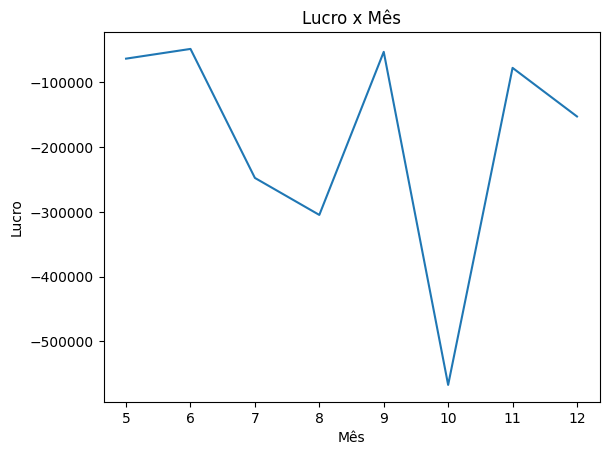

In [45]:
df_2011.groupby(df_2011['OrderDate'].dt.month)['Lucro'].sum().plot(title='Lucro x Mês')
plt.xlabel('Mês')
plt.ylabel('Lucro');

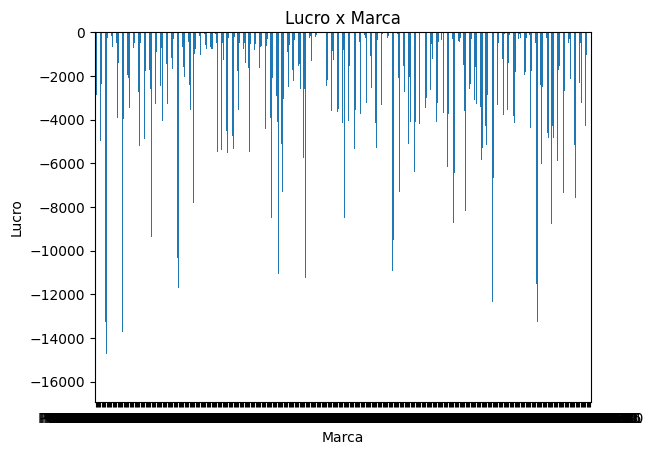

In [44]:
df_2011.groupby('PurchaseOrderNumber')['Lucro'].sum().plot.bar(title='Lucro x Marca')
plt.xlabel('Marca')
plt.ylabel('Lucro')
plt.xticks(rotation='horizontal');

In [ ]:
df_2011.groupby('Classe')['Lucro'].sum().plot.bar(title='Lucro x Classe')
plt.xlabel('Classe')
plt.ylabel('Lucro')
plt.xticks(rotation='horizontal');

In [47]:
df['Tempo_envio'].describe()

,Tempo_envio
count,"31,465.00"
mean,7.00
std,0.02
min,7.00
25%,7.00
50%,7.00
75%,7.00
max,8.00


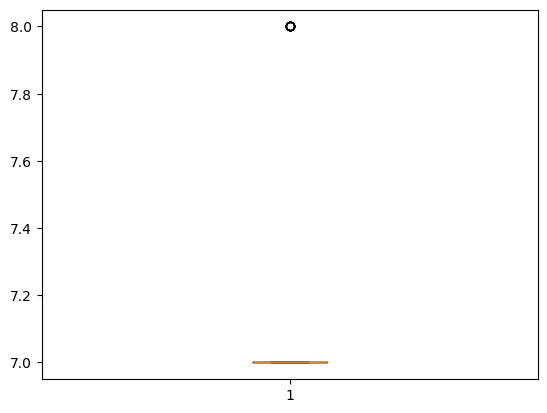

In [48]:
#Gráfico de Boxplot
plt.boxplot(df['Tempo_envio']);

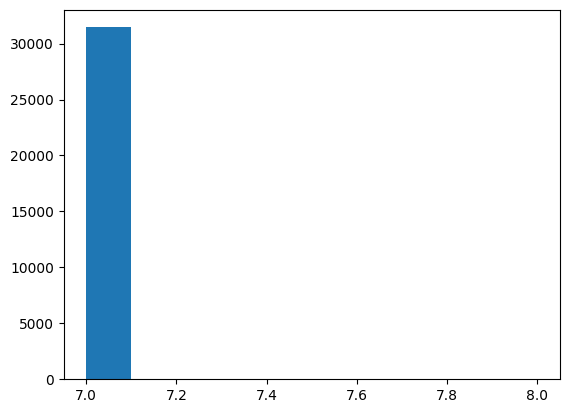

In [50]:
#Histograma
plt.hist(df['Tempo_envio']);

In [ ]:
#Tempo mínimo de envio
df['Tempo_envio'].min()

In [ ]:
#Tempo máximo de envio
df['Tempo_envio'].max()

In [51]:
#Identificando o outlier
df[df['Tempo_envio'] == 8]

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,Comment,rowguid,ModifiedDate,Lucro,Tempo_envio
21430,2078-03-15,9,2014-01-28,2014-02-10,2014-02-05,5,0,SO65089,PO986112457,10-4020-000518,...,"11,077.00","1,466.01",125.66,39.27,"1,630.94",NaN,91858E70-0B81-4E96-8CD1-A25A7A79EA3A,2014-02-05,-164.93,8
21431,2078-03-16,9,2014-01-28,2014-02-10,2014-02-05,5,0,SO65090,PO5481126157,10-4020-000014,...,"11,077.00",98.77,7.90,2.47,109.15,NaN,9363F316-FD43-4003-8B8F-1D220DC39083,2014-02-05,-10.37,8
23543,2083-12-27,9,2014-02-28,2014-03-13,2014-03-08,5,0,SO67202,PO1682155237,10-4020-000572,...,NaN,249.54,19.96,6.24,275.74,NaN,B52687C1-C0A9-4063-96C2-4789E03227B6,2014-03-08,-26.20,8
23544,2083-12-28,9,2014-02-28,2014-03-13,2014-03-08,5,0,SO67203,PO5423131670,10-4020-000639,...,"11,418.00","2,465.23",214.52,67.04,"2,746.79",NaN,C6856A42-A289-4BF3-ADEA-86BE8F1E8DE8,2014-03-08,-281.56,8
23545,2083-12-29,9,2014-02-28,2014-03-13,2014-03-08,5,0,SO67204,PO5916191420,10-4020-000392,...,"11,418.00",515.87,44.60,13.94,574.41,NaN,36A45E67-1859-4224-9FEE-AB5B694EB400,2014-03-08,-58.54,8
25650,2089-10-03,9,2014-03-30,2014-04-12,2014-04-07,5,0,SO69309,PO11281123848,10-4020-000068,...,"11,748.00","7,041.57",563.60,176.12,"7,781.29",NaN,15BB6FC3-47DA-46E9-8C57-600C0D4E790D,2014-04-07,-739.72,8
25651,2089-10-04,9,2014-03-30,2014-04-12,2014-04-07,5,0,SO69310,PO19140122828,10-4020-000681,...,"11,748.00",249.54,19.96,6.24,275.74,NaN,DE05AF1D-4166-4E03-8FA2-4F321B08BC5C,2014-04-07,-26.20,8
28032,2096-04-11,9,2014-04-30,2014-05-13,2014-05-08,5,0,SO71691,PO4321155972,10-4020-000104,...,"12,089.00","1,087.24",93.77,29.30,"1,210.32",NaN,78F05D67-CB75-4E66-8A8F-396B79134D95,2014-05-08,-123.08,8
28033,2096-04-12,9,2014-04-30,2014-05-13,2014-05-08,5,0,SO71692,PO5481166684,10-4020-000014,...,"12,089.00",197.55,15.80,4.94,218.29,NaN,87391478-3D17-4DA8-9508-738F30CAC1DB,2014-05-08,-20.74,8


In [52]:
df.to_csv('df_pedido.csv', index=False)